In [1]:
# import torch

# print(torch.__version__)
# print(torch.version.cuda)
# print(torch.cuda.is_available())
# print(torch.cuda.get_device_name(0))

In [2]:
# import os

# event_path = r"C:\Users\ASUS\Downloads\Next_gen_proj\mmflood\mmflood\EMSR107-5"

# for root, dirs, files in os.walk(event_path):

#     print("\nFOLDER:", root)

#     for file in files[:10]:
#         # print(file)

# import os

# s1_path = r"C:\Users\ASUS\Downloads\Next_gen_proj\mmflood\mmflood\EMSR107-5\s1_raw"

# files = os.listdir(s1_path)

# print("Total files:", len(files))

# for file in files[:30]:
#     print(file)

In [3]:
# import rasterio

# sample_path = r"C:\Users\ASUS\Downloads\Next_gen_proj\mmflood\mmflood\EMSR107-5\s1_raw\EMSR107-5-0.tif"

# with rasterio.open(sample_path) as src:

#     print("Number of bands:", src.count)

#     print("Width:", src.width)

#     print("Height:", src.height)

#     print("Data type:", src.dtypes)

#     print("CRS:", src.crs)


In [4]:
# import rasterio
# import matplotlib.pyplot as plt

# sample_path = r"C:\Users\ASUS\Downloads\Next_gen_proj\mmflood\mmflood\EMSR107-5\s1_raw\EMSR107-5-0.tif"

# with rasterio.open(sample_path) as src:

#     image = src.read()

# print("Shape:", image.shape)

# vv = image[0]
# vh = image[1]

# plt.figure(figsize=(12,5))

# plt.subplot(1,2,1)
# plt.imshow(vv, cmap='gray')
# plt.title("VV Band")

# plt.subplot(1,2,2)
# plt.imshow(vh, cmap='gray')
# plt.title("VH Band")

# plt.show()

# mask_path = r"C:\Users\ASUS\Downloads\Next_gen_proj\mmflood\mmflood\EMSR107-5\mask\EMSR107-5-0.tif"

# with rasterio.open(mask_path) as src:

#     mask = src.read(1)

# print("Mask shape:", mask.shape)

# plt.figure(figsize=(6,6))
# plt.imshow(mask, cmap='gray')
# plt.title("Flood Mask")
# plt.show()

In [5]:
# import numpy as np
# import matplotlib.pyplot as plt
# import rasterio

# sample_path = r"C:\Users\ASUS\Downloads\Next_gen_proj\mmflood\mmflood\EMSR107-5\s1_raw\EMSR107-5-0.tif"

# with rasterio.open(sample_path) as src:

#     image = src.read()

# vv = image[0]
# vh = image[1]

# # NORMALIZATION FUNCTION
# def normalize(img):

#     img = np.nan_to_num(img)

#     lower = np.percentile(img, 2)
#     upper = np.percentile(img, 98)

#     img = np.clip(img, lower, upper)

#     img = (img - img.min()) / (img.max() - img.min() + 1e-8)

#     return img

# vv_norm = normalize(vv)
# vh_norm = normalize(vh)

# plt.figure(figsize=(12,5))

# plt.subplot(1,2,1)
# plt.imshow(vv_norm, cmap='gray')
# plt.title("VV Normalized")

# plt.subplot(1,2,2)
# plt.imshow(vh_norm, cmap='gray')
# plt.title("VH Normalized")

# plt.show()

In [6]:
import os
from glob import glob

root_dir = r"C:\Users\ASUS\Downloads\Next_gen_proj\mmflood\mmflood"

image_paths = []
mask_paths = []
dem_paths = []
hydro_paths = []

for event in os.listdir(root_dir):

    event_path = os.path.join(root_dir, event)

    if not os.path.isdir(event_path):
        continue

    s1_dir = os.path.join(event_path, "s1_raw")
    mask_dir = os.path.join(event_path, "mask")
    dem_dir = os.path.join(event_path, "DEM")
    hydro_dir = os.path.join(event_path, "hydro")

    # ALL MODALITIES MUST EXIST
    if not (
        os.path.exists(s1_dir)
        and os.path.exists(mask_dir)
        and os.path.exists(dem_dir)
        and os.path.exists(hydro_dir)
    ):
        continue

    # GET FILES
    s1_files = sorted(glob(os.path.join(s1_dir, "*.tif")))
    mask_files = sorted(glob(os.path.join(mask_dir, "*.tif")))
    dem_files = sorted(glob(os.path.join(dem_dir, "*.tif")))
    hydro_files = sorted(glob(os.path.join(hydro_dir, "*.tif")))

    # CREATE DICTIONARIES
    s1_dict = {
        os.path.basename(f): f
        for f in s1_files
    }

    mask_dict = {
        os.path.basename(f): f
        for f in mask_files
    }

    dem_dict = {
        os.path.basename(f): f
        for f in dem_files
    }

    hydro_dict = {
        os.path.basename(f): f
        for f in hydro_files
    }

    # FIND COMMON FILES
    common_files = set(s1_dict.keys()) & \
                   set(mask_dict.keys()) & \
                   set(dem_dict.keys()) & \
                   set(hydro_dict.keys())

    for file_name in common_files:

        image_paths.append(s1_dict[file_name])

        mask_paths.append(mask_dict[file_name])

        dem_paths.append(dem_dict[file_name])

        hydro_paths.append(hydro_dict[file_name])

print("Final aligned samples:", len(image_paths))

Final aligned samples: 1012


In [7]:
# import rasterio
# import numpy as np

# print("Total samples:", len(mask_paths))

# ratios = []

# for mask_path in mask_paths:

#     with rasterio.open(mask_path) as src:

#         mask = src.read(1)

#     mask = (mask > 0).astype(np.float32)

#     ratios.append(mask.mean())

# print("Min:", np.min(ratios))
# print("Max:", np.max(ratios))
# print("Mean:", np.mean(ratios))
# print("Median:", np.median(ratios))

# empty_masks = 0

# for r in ratios:

#     if r < 0.001:

#         empty_masks += 1

# print("Empty masks:", empty_masks)
# print("Total masks:", len(ratios))
# print(
#     "Percentage:",
#     100 * empty_masks / len(ratios)
# )


In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.1,
        rotate_limit=20,
        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.3),

    A.GaussianBlur(p=0.2),

    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256,256),
    ToTensorV2()
])

c:\Users\ASUS\Downloads\Next_gen_proj\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ASUS\Downloads\Next_gen_proj\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
from matplotlib import image
import torch
import cv2
import rasterio
import numpy as np

from torch.utils.data import Dataset


class MMFloodDataset(Dataset):

    def __init__(
        self,
        image_paths,
        mask_paths,
        dem_paths,
        hydro_paths,
        transform=None
    ):

        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.dem_paths = dem_paths
        self.hydro_paths = hydro_paths
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def read_sar(self, path):

        with rasterio.open(path) as src:

            image = src.read()

        # FLOAT32
        image = image.astype(np.float32)

        # REMOVE NaN / INF
        image = np.nan_to_num(
            image,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        # CLIP EXTREME VALUES
        image = np.clip(image, -30, 30)

        return image

    def read_mask(self, path):

        with rasterio.open(path) as src:

            mask = src.read(1)

        mask = (mask > 0).astype(np.float32)

        return mask

    def read_dem(self, path):

        with rasterio.open(path) as src:

            dem = src.read(1)

        dem = dem.astype(np.float32)

        # REMOVE NaN
        dem = np.nan_to_num(dem)

        return dem
    
    def read_hydro(self, path):

        with rasterio.open(path) as src:

            hydro = src.read(1)

        hydro = hydro.astype(np.float32)

        hydro = np.nan_to_num(hydro)

        return hydro
    
    def __getitem__(self, idx):

        # READ SAR
        image = self.read_sar(
            self.image_paths[idx]
        )
#         print(
#     "SAR range:",
#     image.min(),
#     image.max()
# )

        # READ MASK
        
    # READ MASK
        mask = self.read_mask(
            self.mask_paths[idx]
        )

        # mask_ratio = mask.mean()

        # if mask_ratio < 0.001:

        #     new_idx = np.random.randint(
        #         0,
        #         len(self.image_paths)
        #     )

        #     return self.__getitem__(new_idx)

        # READ DEM
        dem = self.read_dem(
            self.dem_paths[idx]
        )

        # READ HYDRO
        hydro = self.read_hydro(
            self.hydro_paths[idx]
        )

#         print(
#     "Hydro:",
#     hydro.min(),
#     hydro.max(),
#     hydro.mean()
# )
        

        # (C,H,W) → (H,W,C)
        image = np.transpose(
            image,
            (1,2,0)
        )

        # NORMALIZE SAR
        # image_min = image.min()
        # image_max = image.max()

        image = image / 30.0

        image = np.clip(
            image,
            0,
            1
        )

        # NORMALIZE DEM
        dem_min = dem.min()
        dem_max = dem.max()

        dem = (
            dem - dem_min
        ) / (
            dem_max - dem_min + 1e-8
        )

        # NORMALIZE HYDRO
        hydro_min = hydro.min()
        hydro_max = hydro.max()

        hydro = (
            hydro - hydro_min
        ) / (
            hydro_max - hydro_min + 1e-8
        )

        # ADD CHANNEL DIMENSIONS

        # GET SAR SIZE
        h, w, _ = image.shape

        # RESIZE DEM
        dem = cv2.resize(
            dem,
        (w, h),
        interpolation=cv2.INTER_LINEAR
)

# RESIZE HYDRO
        hydro = cv2.resize(
    hydro,
    (w, h),
    interpolation=cv2.INTER_LINEAR
)

# ADD CHANNEL DIMENSIONS
        dem = np.expand_dims(
    dem,
    axis=-1
)

        hydro = np.expand_dims(
    hydro,
    axis=-1
)
        # CONCATENATE
        image = np.concatenate(
    [image, dem, hydro],
    axis=-1
)

        # -------------------------
        # PATCH SAMPLING
        # -------------------------

        PATCH_SIZE = 256

        mask_full = mask

        found = False

        for _ in range(50):

            y = np.random.randint(
                0,
                h - PATCH_SIZE
            )

            x = np.random.randint(
                0,
                w - PATCH_SIZE
            )

            temp_mask = mask_full[
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            if temp_mask.mean() > 0.03:

                found = True

                break

        if not found:

            non_empty = np.where(mask_full > 0)

            if len(non_empty[0]) > 0:

                center_y = non_empty[0][0]
                center_x = non_empty[1][0]

                y = np.clip(
                    center_y - PATCH_SIZE // 2,
                    0,
                    h - PATCH_SIZE
            )

            x = np.clip(
                center_x - PATCH_SIZE // 2,
                0,
                w - PATCH_SIZE
            )

        # print(
        #     "Selected mask ratio:",
        #     temp_mask.mean()
        # )

        # EXTRACT PATCHES
        image = image[
            y:y+PATCH_SIZE,
            x:x+PATCH_SIZE
        ]

        mask = mask_full[
            y:y+PATCH_SIZE,
            x:x+PATCH_SIZE
        ]

        hydro_patch = hydro[
            y:y+PATCH_SIZE,
            x:x+PATCH_SIZE
        ]

        # SAFETY CHECK
        if image.shape[0] != PATCH_SIZE or image.shape[1] != PATCH_SIZE:

            image = cv2.resize(
                image,
                (PATCH_SIZE, PATCH_SIZE)
            )

            mask = cv2.resize(
                mask,
                (PATCH_SIZE, PATCH_SIZE),
                interpolation=cv2.INTER_NEAREST
            )

        # print(
        #     "Hydro mean:",
        #     hydro_patch.mean()
        # )
#         print(
#     "Hydro pixels:",
#     np.sum(hydro_patch > 0)
# )
        

        # APPLY AUGMENTATION
        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]

            mask = augmented["mask"]

        # ADD MASK CHANNEL
        mask = mask.unsqueeze(0)

        return image, mask

In [10]:
dataset = MMFloodDataset(
    image_paths=image_paths,
    mask_paths=mask_paths,
    dem_paths=dem_paths,
    hydro_paths=hydro_paths,
    transform=train_transform
)

image, mask = dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

raw = dataset.read_sar(
    image_paths[0]
)

print(raw.min())
print(raw.max())
print(raw.mean())

hydro = dataset.read_hydro(
    hydro_paths[0]
)

print(
    hydro.min(),
    hydro.max(),
    hydro.mean()
)

# empty_masks = 0

# for mask_path in mask_paths:

#     mask = dataset.read_mask(mask_path)

#     if mask.mean() < 0.001:

#         empty_masks += 1

# print("Empty masks:", empty_masks)
# print("Total masks:", len(mask_paths))
# print(
#     "Percentage:",
#     100 * empty_masks / len(mask_paths)
# )


Image shape: torch.Size([4, 256, 256])
Mask shape: torch.Size([1, 256, 256])
0.00047019921
30.0
0.13501632
0.0 1.0 0.00075617543


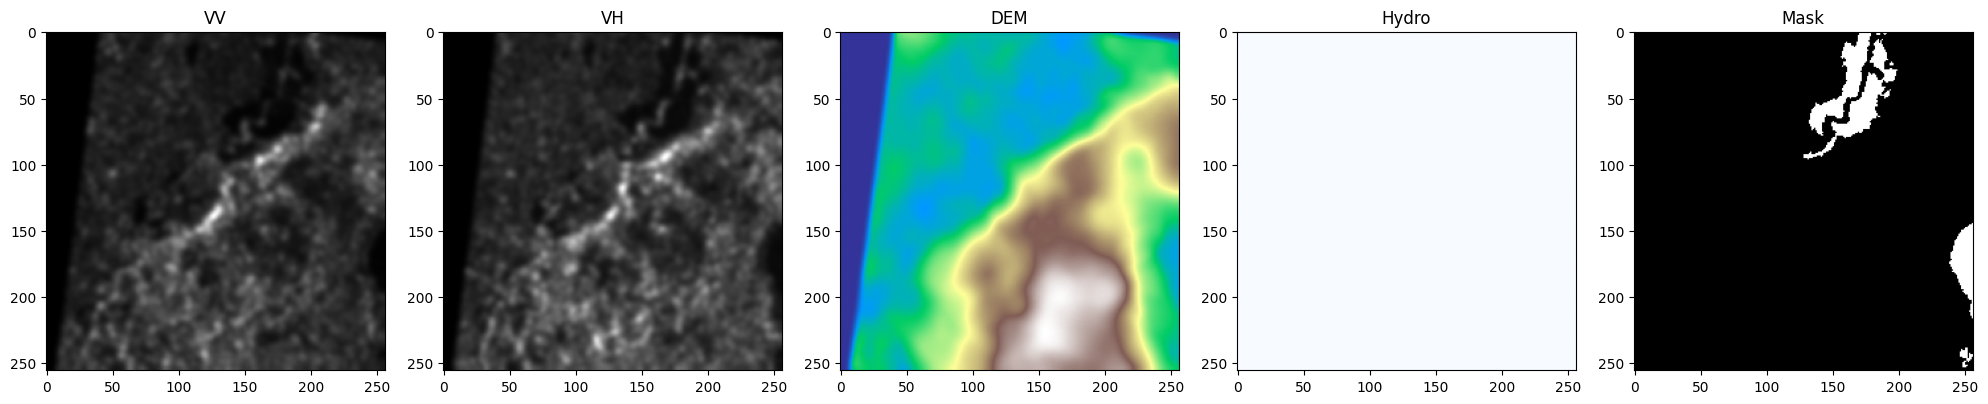

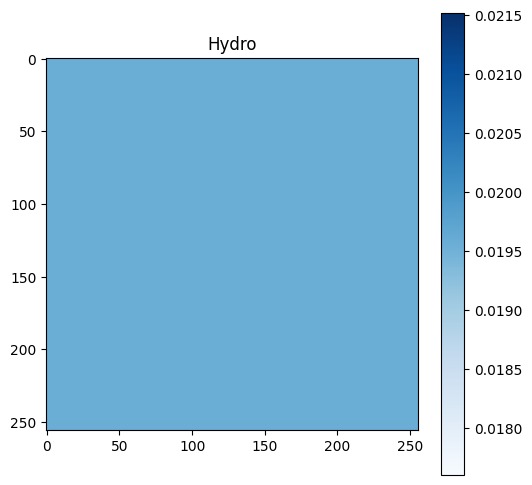

0.019560399 0.019560399 0.019560399


In [11]:
import matplotlib.pyplot as plt

image_np = image.numpy()

mask_np = mask.squeeze().numpy()

vv = image_np[0]

vh = image_np[1]

dem = image_np[2]

hydro = image_np[3]

plt.figure(figsize=(20,4))

# VV
plt.subplot(1,5,1)

plt.imshow(vv, cmap='gray')

plt.title("VV")

# VH
plt.subplot(1,5,2)

plt.imshow(vh, cmap='gray')

plt.title("VH")

# DEM
plt.subplot(1,5,3)

plt.imshow(dem, cmap='terrain')

plt.title("DEM")

# HYDRO
plt.subplot(1,5,4)

plt.imshow(hydro, cmap='Blues')

plt.title("Hydro")

# MASK
plt.subplot(1,5,5)

plt.imshow(mask_np, cmap='gray')

plt.title("Mask")

plt.tight_layout()

plt.show()

plt.figure(figsize=(6,6))
plt.imshow(hydro, cmap='Blues')
plt.colorbar()
plt.title("Hydro")
plt.show()

print(
    hydro.min(),
    hydro.max(),
    hydro.mean()
)


In [12]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_masks, val_masks, train_dem,val_dem,train_hydro, val_hydro= train_test_split(
    image_paths,
    mask_paths,
    dem_paths,
    hydro_paths,
    test_size=0.2,
    random_state=42
)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))

Train images: 809
Validation images: 203


In [13]:
train_dataset = MMFloodDataset(
    train_images,
    train_masks,
    train_dem,
    train_hydro,
    transform=train_transform
)

val_dataset = MMFloodDataset(
    val_images,
    val_masks,
    val_dem,
    val_hydro,
    transform=val_transform
)

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    # persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=True, 
    # persistent_workers=True
)

images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

sample_image, sample_mask = train_dataset[0]

print(
    "Final image range:",
    sample_image.min().item(),
    sample_image.max().item()
)

# sample_image, sample_mask = train_dataset[0]

# print(
#     sample_image[0].min().item(),
#     sample_image[0].max().item()
# )

# print(
#     sample_image[1].min().item(),
#     sample_image[1].max().item()
# )

# image, mask = train_dataset[0]

# print("Tensor min:", image.min().item())
# print("Tensor max:", image.max().item())
# print("Tensor mean:", image.mean().item())

# print(train_transform)
# print(val_transform)


torch.Size([2, 4, 256, 256])
torch.Size([2, 1, 256, 256])
Final image range: 0.0 0.6910972595214844


In [14]:
import segmentation_models_pytorch as smp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=4,
    classes=1
)

model = model.to(device)

print("Model ready")

dice_loss = smp.losses.DiceLoss(
    mode='binary'
)

bce_loss = torch.nn.BCEWithLogitsLoss()

def loss_fn(pred, target):

    dice = dice_loss(pred, target)

    bce = bce_loss(pred, target)

    return dice + bce

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='max',

    factor=0.5,

    patience=3
)

images = images.to(device)
masks = masks.to(device)

outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)
print("Mask  :", masks.shape)

Model ready
Input : torch.Size([2, 4, 256, 256])
Output: torch.Size([2, 1, 256, 256])
Mask  : torch.Size([2, 1, 256, 256])


In [15]:
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

def train_one_epoch(model, loader, optimizer, loss_fn, device):

    model.train()

    epoch_loss = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        # MIXED PRECISION
        with autocast("cuda"):

            outputs = model(images)

            loss = loss_fn(outputs, masks)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

def validate(model, loader, loss_fn, device):

    model.eval()

    val_loss = 0

    total_iou = 0

    total_acc = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)

            masks = masks.to(device)

            outputs = model(images)

            loss = loss_fn(outputs, masks)

            iou = iou_score(outputs, masks)

            acc = pixel_accuracy(outputs, masks)

            val_loss += loss.item()

            total_iou += iou

            total_acc += acc

    avg_loss = val_loss / len(loader)

    avg_iou = total_iou / len(loader)

    avg_acc = total_acc / len(loader)

    return avg_loss, avg_iou, avg_acc

def iou_score(pred, target, threshold=0.3):

    pred = torch.sigmoid(pred)

    pred = (pred > threshold).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    iou = (intersection + 1e-8) / (union + 1e-8)

    return iou.item()

def validate_iou(model, loader, threshold=0.3):

    model.eval()

    total_iou = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)

            masks = masks.to(device)

            outputs = model(images)

            outputs = torch.sigmoid(outputs)

            preds = (
                outputs > threshold
            ).float()

            intersection = (
                preds * masks
            ).sum()

            union = (
                preds.sum()
                + masks.sum()
                - intersection
            )

            iou = (
                intersection + 1e-8
            ) / (
                union + 1e-8
            )

            total_iou += iou.item()

    return total_iou / len(loader)

def pixel_accuracy(pred, target, threshold=0.3):

    # SIGMOID
    pred = torch.sigmoid(pred)

    # THRESHOLD
    pred = (pred > threshold).float()

    # CORRECT PIXELS
    correct = (pred == target).float().sum()

    # TOTAL PIXELS
    total = torch.numel(pred)

    accuracy = correct / total

    return accuracy.item()

In [16]:
num_epochs = 50
best_iou = 0

train_losses = []

val_losses = []

val_ious = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        loss_fn,
        device
    )

    val_loss, val_iou , val_acc= validate(
    model,
    val_loader,
    loss_fn,
    device
)
    train_losses.append(train_loss)

    val_losses.append(val_loss)

    val_ious.append(val_iou)
    
    scheduler.step(val_iou)

    print(f"Epoch {epoch+1}/{num_epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation IoU: {val_iou:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

    print(f"Validation Accuracy: {val_acc:.4f}")

    if val_iou > best_iou:

        best_iou = val_iou

        torch.save(
        model.state_dict(),
        "best_model.pth"
    )

        print("Best IoU Model Saved!")

Epoch 1/50
Train Loss: 1.2113
Validation IoU: 0.1270
Validation Loss: 1.0997
Validation Accuracy: 0.8871
Best IoU Model Saved!
Epoch 2/50
Train Loss: 1.0353
Validation IoU: 0.2040
Validation Loss: 0.9904
Validation Accuracy: 0.8974
Best IoU Model Saved!
Epoch 3/50
Train Loss: 0.9962
Validation IoU: 0.2340
Validation Loss: 0.9159
Validation Accuracy: 0.9062
Best IoU Model Saved!
Epoch 4/50
Train Loss: 0.9595
Validation IoU: 0.2326
Validation Loss: 0.9217
Validation Accuracy: 0.9302
Epoch 5/50
Train Loss: 0.9481
Validation IoU: 0.2542
Validation Loss: 0.8705
Validation Accuracy: 0.9260
Best IoU Model Saved!
Epoch 6/50
Train Loss: 0.9259
Validation IoU: 0.2661
Validation Loss: 0.8537
Validation Accuracy: 0.9163
Best IoU Model Saved!
Epoch 7/50
Train Loss: 0.9298
Validation IoU: 0.2707
Validation Loss: 0.8752
Validation Accuracy: 0.9246
Best IoU Model Saved!
Epoch 8/50
Train Loss: 0.9280
Validation IoU: 0.2691
Validation Loss: 0.8471
Validation Accuracy: 0.9317
Epoch 9/50
Train Loss: 0.905

Best model loaded!
Threshold=0.1  IoU=0.2789
Threshold=0.2  IoU=0.2972
Threshold=0.3  IoU=0.2947
Threshold=0.4  IoU=0.3023
Threshold=0.5  IoU=0.3132

Best Threshold: 0.5
Best IoU: 0.3132497839034228

Probability Statistics
Prob min: 1.6204551229748176e-06
Prob max: 0.9447928667068481
Prob mean: 0.025398213416337967


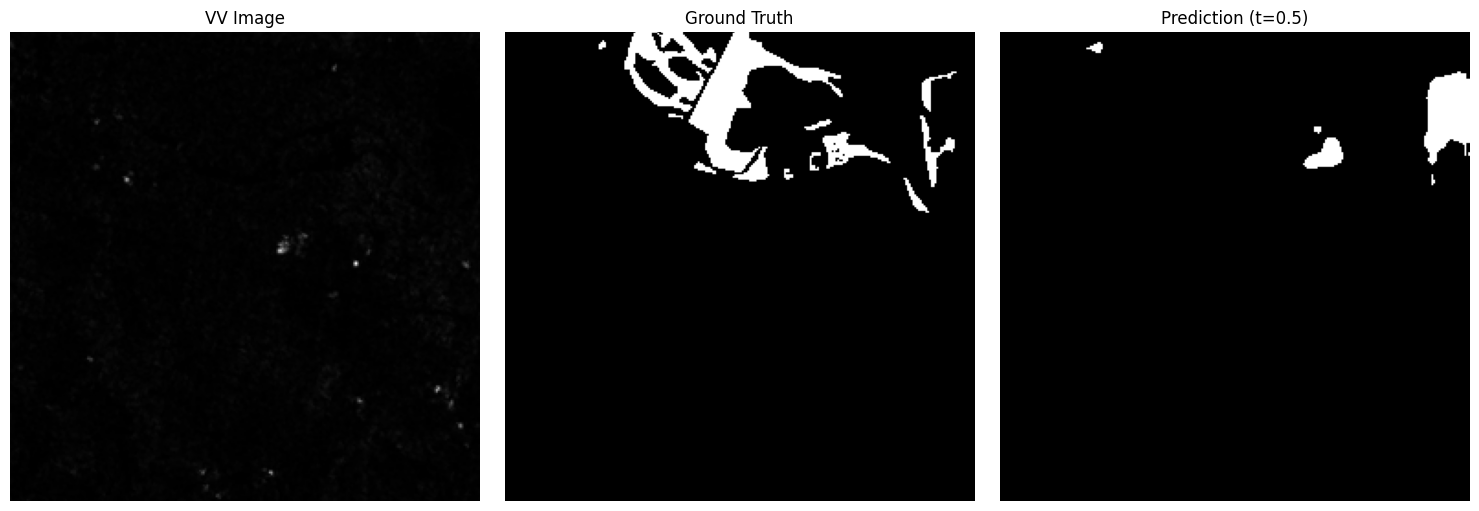

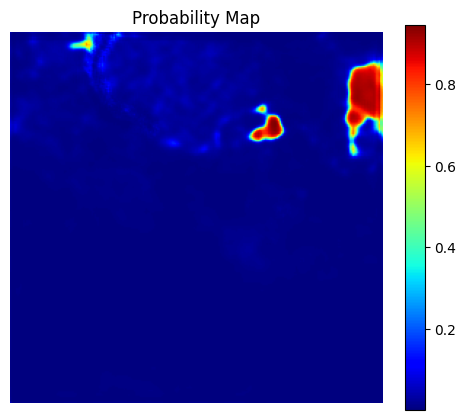

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# LOAD BEST MODEL
# -----------------------------
model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded!")

# -----------------------------
# FIND BEST THRESHOLD
# -----------------------------
thresholds = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5
]

best_threshold = 0
best_iou = 0

for t in thresholds:

    iou = validate_iou(
        model,
        val_loader,
        threshold=t
    )

    print(
        f"Threshold={t}  IoU={iou:.4f}"
    )

    if iou > best_iou:

        best_iou = iou
        best_threshold = t

print("\nBest Threshold:", best_threshold)
print("Best IoU:", best_iou)

# -----------------------------
# GET ONE VALIDATION BATCH
# -----------------------------
images, masks = next(
    iter(val_loader)
)

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

outputs = torch.sigmoid(outputs)

# MOVE TO CPU
images = images.cpu()
masks = masks.cpu()
outputs = outputs.cpu()

# -----------------------------
# FIRST SAMPLE
# -----------------------------
image = images[0]

mask = masks[0,0]

prob = outputs[0,0]

pred = (
    prob > best_threshold
).float()

# -----------------------------
# PROBABILITY STATS
# -----------------------------
print(
    "\nProbability Statistics"
)

print(
    "Prob min:",
    prob.min().item()
)

print(
    "Prob max:",
    prob.max().item()
)

print(
    "Prob mean:",
    prob.mean().item()
)

# -----------------------------
# VISUALIZATION
# -----------------------------
vv = image[0]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(
    vv,
    cmap="gray"
)

plt.title("VV Image")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(
    mask,
    cmap="gray"
)

plt.title("Ground Truth")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(
    pred,
    cmap="gray"
)

plt.title(
    f"Prediction (t={best_threshold})"
)

plt.axis("off")

plt.tight_layout()

plt.show()

# -----------------------------
# PROBABILITY MAP
# -----------------------------
plt.figure(figsize=(6,5))

plt.imshow(
    prob,
    cmap="jet"
)

plt.colorbar()

plt.title(
    "Probability Map"
)

plt.axis("off")

plt.show()

Best model loaded!
Threshold=0.1  IoU=0.2777
Threshold=0.2  IoU=0.3111
Threshold=0.3  IoU=0.3185
Threshold=0.4  IoU=0.2934
Threshold=0.5  IoU=0.3095

Best Threshold: 0.3
Best IoU: 0.3185259397782474


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

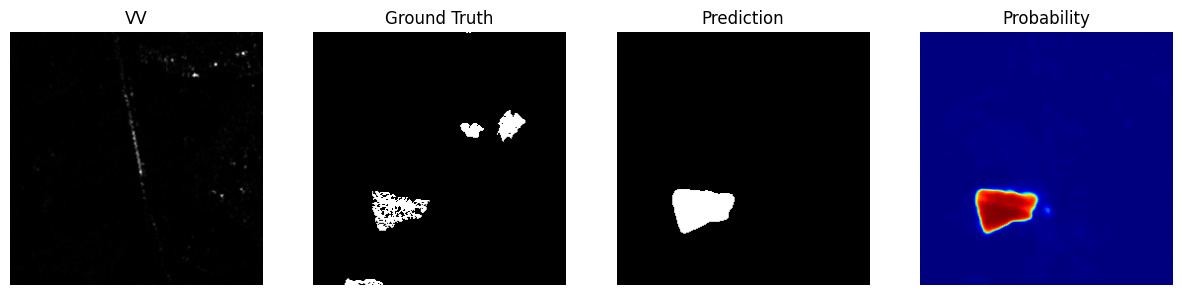

In [18]:
import matplotlib.pyplot as plt
import torch

# LOAD BEST MODEL
model.load_state_dict(
    torch.load("best_model.pth")
)

model.eval()

print("Best model loaded!")

# GET VALIDATION BATCH
images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

# APPLY SIGMOID
outputs = torch.sigmoid(outputs)

# MOVE TO CPU
images = images.cpu()

masks = masks.cpu()

outputs = outputs.cpu()

# NUMBER OF SAMPLES
num_samples = len(images)

plt.figure(figsize=(15, num_samples * 5))

for i in range(num_samples):

    image = images[i]

    mask = masks[i,0]

    prob = outputs[i,0]

    # THRESHOLD
thresholds = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
]

best_threshold = 0
best_iou = 0

for t in thresholds:

    iou = validate_iou(
        model,
        val_loader,
        threshold=t
    )

    print(
        f"Threshold={t}  IoU={iou:.4f}"
    )

    if iou > best_iou:

        best_iou = iou
        best_threshold = t

print("\nBest Threshold:", best_threshold)
print("Best IoU:", best_iou)

import cv2
import numpy as np

pred = (prob > best_threshold).float()

pred_np = pred.numpy().astype(np.uint8)

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    pred_np,
    connectivity=8
)

cleaned = np.zeros_like(pred_np)

for j in range(1, num_labels):

    area = stats[j, cv2.CC_STAT_AREA]

    if area > 20:

        cleaned[labels == j] = 1

vv = image[0]

plt.subplot(num_samples, 4, i*4 + 1)
plt.imshow(vv, cmap='gray')
plt.title("VV")
plt.axis("off")

plt.subplot(num_samples, 4, i*4 + 2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(num_samples, 4, i*4 + 3)
plt.imshow(cleaned, cmap='gray')
plt.title("Prediction")
plt.axis("off")

plt.subplot(num_samples, 4, i*4 + 4)
plt.imshow(prob.numpy(), cmap='jet')
plt.title("Probability")
plt.axis("off")


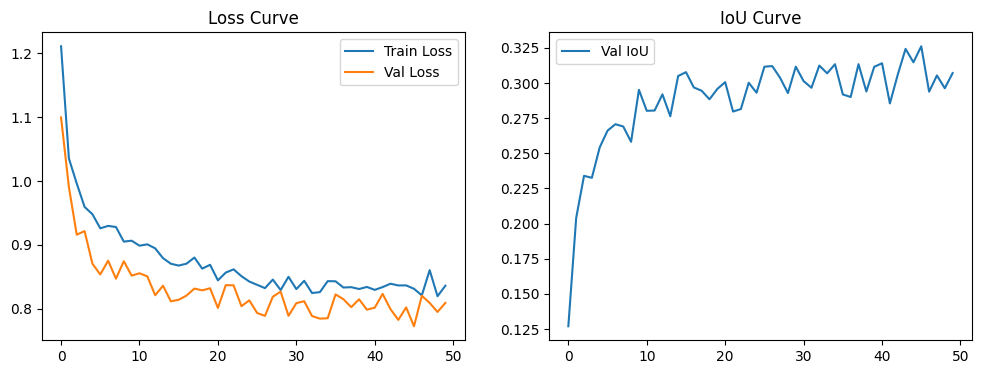

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# LOSS
plt.subplot(1,2,1)

plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Val Loss')

plt.legend()

plt.title("Loss Curve")

# IOU
plt.subplot(1,2,2)

plt.plot(val_ious, label='Val IoU')

plt.legend()

plt.title("IoU Curve")

plt.show()

In [20]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import numpy as np
import torch

# LOAD BEST MODEL
model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

model.eval()
all_preds = []
all_masks = []

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)

        outputs = model(images)

        outputs = torch.sigmoid(outputs)

        preds = (outputs > best_threshold).float()

        preds = preds.cpu().numpy()

        masks = masks.cpu().numpy()

        all_preds.append(
            preds.reshape(-1)
        )

        all_masks.append(
            masks.reshape(-1)
        )

# CONCATENATE ALL PIXELS
all_preds = np.concatenate(
    all_preds
)

all_masks = np.concatenate(
    all_masks
)

# METRICS
precision = precision_score(
    all_masks,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_masks,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_masks,
    all_preds,
    zero_division=0
)

intersection = np.logical_and(
    all_preds,
    all_masks
).sum()

union = np.logical_or(
    all_preds,
    all_masks
).sum()

iou = intersection / (
    union + 1e-8
)

print("\n===== FINAL METRICS =====")

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)

print(
    f"IoU       : {iou:.4f}"
)


===== FINAL METRICS =====
Precision : 0.3961
Recall    : 0.6817
F1 Score  : 0.5011
IoU       : 0.3343


In [21]:
print(
    "Prob min:",
    prob.min().item()
)

print(
    "Prob max:",
    prob.max().item()
)

print(
    "Prob mean:",
    prob.mean().item()
)

Prob min: 5.947119916527299e-06
Prob max: 0.980857253074646
Prob mean: 0.030459966510534286
